# Reinforcement learning 

## Concept

Reinforcement Learning is a type of Machine Learning where an agent learns by interacting with an environment and receiving rewards or penalties based on its actions.

👉 The main goal:

Learn the best actions to maximize total reward.

🎯 Real-Life Analogy

Think about teaching a dog:

✅ Give treat for correct action → Reward
❌ Ignore/warn for wrong action → Penalty

Over time, the dog learns:

“Which action gives maximum reward?”

That is exactly how Reinforcement Learning works.

🧩 Main Components of Reinforcement Learning
1️⃣ Agent

The learner or decision-maker.

Example:

Robot
Self-driving car
Game-playing AI
2️⃣ Environment

The world in which the agent operates.

Example:

Chess board
Road for self-driving car
Video game
3️⃣ Action

What the agent does.

Example:

Move left/right
Accelerate
Pick an object
4️⃣ Reward

Feedback from environment.

Positive reward → Good action
Negative reward → Bad action

Example:

+10 for winning game
-5 for collision
5️⃣ State

Current situation of the environment.

Example:

Position of robot
Current game board
🔄 Working Process
Step-by-Step
Agent observes environment
Agent takes action
Environment gives reward
Agent learns from reward
Process repeats
🧠 Core Objective

The agent tries to learn:

“Which action gives maximum long-term reward?”

📌 Example: Self-Driving Car
Rewards:
✅ Staying in lane → +10
✅ Reaching destination → +100
❌ Collision → -100

Over time:

Car learns safe driving behavior
🔥 Types of Reinforcement Learning
1️⃣ Positive Reinforcement

Reward for correct action.

Example:

Robot gets reward for reaching goal.
2️⃣ Negative Reinforcement

Penalty for wrong action.

Example:

Robot loses points for hitting wall.
⚡ Important Terms
📌 Policy

Strategy followed by agent.

👉 “What action should I take?”

📌 Q-Value

Measures how good an action is in a state.

📌 Exploration vs Exploitation
Exploration

Try new actions.

Exploitation

Use already learned best action.

RL balances both.

🧠 Difference Between Supervised Learning and Reinforcement Learning
Supervised Learning	Reinforcement Learning
Learns from labeled data	Learns from rewards
Correct answers provided	No direct correct answer
Example: Spam detection	Example: Game AI
🚀 Applications of Reinforcement Learning
🎮 Game Playing AI
🚗 Self-driving cars
🤖 Robotics
📈 Stock trading
🏭 Industrial automation
🎯 Recommendation systems
🎮 Famous Example

DeepMind created:

AlphaGo
AlphaZero

These systems learned games using Reinforcement Learning.

🔥 Advantages

✅ Learns automatically
✅ Handles dynamic environments
✅ Improves through experience

⚠️ Disadvantages

❌ Needs large training time
❌ Requires many interactions
❌ Complex tuning

# Upper Confidence bound

## concept

Upper Confidence Bound (UCB) is a technique used in Reinforcement Learning and the Multi-Armed Bandit Problem to balance:

✅ Exploration
✅ Exploitation
🎯 Main Idea of UCB

UCB helps an agent decide:

“Should I try a new option or continue with the best-known option?”

🎰 Real-Life Example: Slot Machines

Imagine a casino with many slot machines.

Each machine gives different rewards.

Problem:

Which machine should you play to maximize reward?
⚡ Two Challenges
1️⃣ Exploitation

Choose machine giving highest reward so far.

👉 Safe choice

2️⃣ Exploration

Try less-used machines to check if they are better.

👉 Discover new possibilities

🧠 UCB Solves This Balance

UCB selects:

Machines with high reward
AND machines with less experience (uncertainty)
📌 Formula of UCB
🧩 Meaning of Terms
Symbol	Meaning

xi -Average reward of machine i
n = total number of rounds 
ni	= number of times machine i selected

### ​Formula Intuition

UCB has TWO parts:

✅ Part 1: Average Reward
x̄i
Exploitation part
Choose machine performing well

Part 2: Confidence Interval
√(2ln(n)/ni)
Exploration part
Gives chance to less-tested machines

Key Insight

If a machine is selected very few times:

n
i
	​

 becomes small
Confidence term becomes BIG

👉 Algorithm explores it more.

###  Working of UCB
Step-by-Step
1. Select each option at least once
2. Compute UCB for each option
3. Choose option with highest UCB
4. Update rewards
5. Repeat


### Example

Suppose:

Ad	Average Reward	Times Selected
A	8	100
B	7	5

Even though B has lower reward:

It was tested very little
UCB may still choose B

👉 Because it could become better later.

###  Applications of UCB
Online advertising
Recommendation systems
Clinical trials
Game AI
Dynamic pricing
### UCB vs Random Selection
Random	            |  UCB
1. Chooses randomly	|Chooses intelligently
2. May waste time	    |Faster optimization
3. No learning	        |Learns continuously


### Advantages of UCB

✅ Balances exploration and exploitation
✅ Efficient decision-making
✅ Improves reward over time

### Limitation

❌ Assumes reward distribution is stable
❌ Computationally heavier than random methods
    
### Exploration :
Trying new or less-used options to gain more information.

👉 The agent tests unknown possibilities.

📌 Example

Suppose:

Ad B was shown only a few times.

The system may still try Ad B to check:

“Maybe this ad performs even better.”

This is exploration.

✅ Goal of Exploration
Discover potentially better actions
Reduce uncertainty

### Exploitation: 
Using the option that currently gives the best reward.

👉 The agent chooses what it already knows is good.

📌 Example

Suppose:

Ad A gives high clicks repeatedly.

Then:

The system keeps showing Ad A.

This is exploitation.

✅ Goal of Exploitation
Maximize immediate reward
Use known best action

### Exploration vs Exploitation
Exploration	           |  exploitation
Try new options	       |Use best-known option
Gains knowledge        |Gains reward
Risky	               |Safe
Long-term learning	   |Short-term benefit

### Why Balance is Important

If only exploitation:

Agent may miss better options.

If only exploration:

Agent wastes time testing poor options.

👉 Good systems balance both.

###  How UCB Handles This

Upper Confidence Bound automatically balances:

High reward options → exploitation
Less-tested options → exploration


## Importing the libraries

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Importing the dataset 

In [12]:
dataset = pd.read_csv('Ads_CTR_Optimisation.csv')

# in the datset  all the adds has different conversion rate (ie. ad1 -different coversion rate , ad2 -- different conersion rate  .... here each ad has different click through rate )

## implementing UCB

In [13]:
# Steps to implement UCB. Step 1. At each round n, we consider two numbers for each ad i. n_i(n) is the number of times the ad i was selected up to round n. r_i(n) here the number, the sum of rewards of the ad i up to the round n. Step 2. From these two numbers, we compute the average reward of ad i up to round n, r̄_i(n) = R_i(n) / n_i(n). The confidence interval mod of r̄_i(n) minus change in triangle of n, r̄_i(n) plus triangle_i(n) at round n with triangle_i(n) equal to square root of 3/2 log n divided by n_i(n). Step 3. We select the ad i that has the maximum UCB, r̄_i(n) plus triangle_i(n).

In [15]:
import math
N = 10000 # number of user in a dataset 
d = 10 # number of adds in a dataset 
ads_selected =[]

numbers_of_selection = [0] * d #number of times the each add has been selected
 # intialising the list of 10 zeroes
 # each time it will increment when the add gets selected 

sums_of_rewards= [0]*d # as the adds get selected the rewards will increase

total_rewards=0 #shows the total collected reward , at starting its initialised with zero as initoally no award has collected 


for n in range(0,N):
    ad = 0 # starting with adds  here 0 is index of add 1 and here we are also comparing higher UCB values
    max_upper_bound= 0 # this will get updated while we are getting max / higher vlues as upper UCB
    for i in range(0,d): # this will iterate through each add (columns)
        if (numbers_of_selection[i]>0): # if lrger than 0 the add is selected 
            average_reward = sums_of_rewards[i] / numbers_of_selection[i]
            delta_i = math.sqrt(3/2 * math.log(n+1) / numbers_of_selection[i])
            upper_bound = average_reward + delta_i

# the add will not got selected must be selected 
        else:
            upper_bound= 1e400
        
# to make sure the selected add has high upper bound 
        if (upper_bound > max_upper_bound):
            max_upper_bound = upper_bound # updating ads with higher UCB
            ad = i 

# updatig all the variabkles
    ads_selected.append(ad)
    numbers_of_selection[ad]= numbers_of_selection[ad]+i
    reward = dataset.values[n,ad]
    sums_of_rewards[ad] = sums_of_rewards[ad]+dataset.values[n,ad]+reward
    total_rewards= total_rewards + reward 





## visulaizing the results 

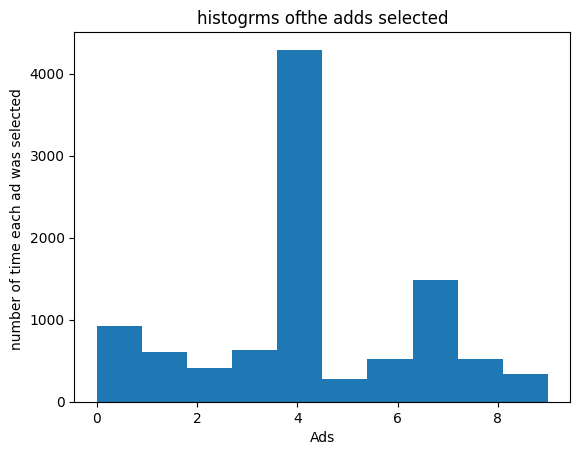

In [16]:
plt.hist(ads_selected)
plt.title('histogrms ofthe adds selected')
plt.xlabel('Ads')
plt.ylabel('number of time each ad was selected ')
plt.show()